# **Análisis de Comentarios de Encuestas de Satisfacción - Sector BPO**

## Identificación de Motivos de Insatisfacción mediante NLP y LLM

**Objetivo:** Utilizar un modelo cognitivo (Gemini 2.5 Flash) para determinar los motivos por los cuales los clientes se muestran inconformes, a partir de los comentarios registrados en las encuestas de satisfacción realizadas al final de cada llamada.

**Pregunta de la encuesta:** *¿Qué le generó esfuerzo o insatisfacción?*

---
## **1. Instalación de Librerías**

Instalamos las librerías necesarias para el análisis. `google-generativeai` nos permite conectarnos a la API de Gemini.

In [1]:
# Instalación de librerías (ejecutar solo la primera vez)
!pip install google-generativeai wordcloud openpyxl python-dotenv -q

## **2. Importar Librerías**

In [2]:
# Librerías de datos y visualización
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
import time
import json
import os
from collections import Counter
from dotenv import load_dotenv

# API de Gemini
import google.generativeai as genai

# Clustering
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Configuración visual
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('Librerías cargadas correctamente ✅')

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


Librerías cargadas correctamente ✅


---
## **3. Carga de Datos**

Cargamos el archivo `comentarios_encuesta.xlsx` que contiene los comentarios de los clientes.

In [3]:
# Si estás en Google Colab, sube el archivo primero:
# from google.colab import files
# uploaded = files.upload()

# Cargar datos
df = pd.read_excel('comentarios_encuesta.xlsx')
print(f'Dataset cargado: {df.shape[0]} registros, {df.shape[1]} columnas')
print(f'Columnas: {df.columns.tolist()}')
df.head(10)

Dataset cargado: 310 registros, 2 columnas
Columnas: ['callid', 'texto']


,callid,texto
0,29b028cc-a9b2-4e54-b485-e6656de23d81,la demora excesiva que provoco incidentes con ...
1,5ce226b3-5d25-427f-a0d3-2ea6eae8bad6,han pasado 5 horas y no se ha dado solucion al...
2,041c2a46-c809-4b72-af63-617d7d100994,sigo con dudano
3,0d33bed6-9151-41ff-8b30-c9a62fa45475,no hubo atencionno hubo atencion
4,2378d312-298d-475a-921f-81fd4687858d,siempre dicen lo mismo y no solucionan rapidotodo
5,f3c8913f-1110-4566-8e86-c2768fe65496,el servicio esta super malo siempre nos quedam...
6,9c05af4e-48c6-47ae-8a45-1c0386d1fc19,no puedo tener serviciono logre resolver
7,37674691-749a-4d5d-acf7-2d8f5352c118,no resuelven nada llevo tres dias en lo mismo ...
8,6b1ea80a-8b9f-4eea-9a71-127f03091bd6,un puto asco la atencion ni siquiera generan u...
9,482b4f93-7b68-4d17-8e8f-5dbe9d2f7f7e,esperar mas de 2 horas el numero de reporte cu...


---
## **4. Análisis Exploratorio de Datos (EDA)**

Exploramos la estructura, calidad y características de los comentarios antes de aplicar el modelo.

### 4.1 Estructura y calidad de los datos

In [4]:
# Información general del dataset
print('='*60)
print('INFORMACIÓN GENERAL DEL DATASET')
print('='*60)
print(f'Total de registros: {len(df)}')
print(f'Columnas: {df.columns.tolist()}')
print(f'\nTipos de datos:')
print(df.dtypes)
print(f'\nValores nulos:')
print(df.isnull().sum())
print(f'\nComentarios duplicados: {df["texto"].duplicated().sum()}')
print(f'Comentarios únicos: {df["texto"].nunique()}')

INFORMACIÓN GENERAL DEL DATASET
Total de registros: 310
Columnas: ['callid', 'texto']

Tipos de datos:
callid    object
texto     object
dtype: object

Valores nulos:
callid    0
texto     0
dtype: int64

Comentarios duplicados: 37
Comentarios únicos: 273


### 4.2 Análisis de longitud de los comentarios

Estadísticas de longitud de comentarios:
       longitud  num_palabras
count     310.0         310.0
mean       54.7          10.2
std        32.3           6.1
min         6.0           1.0
25%        29.2           6.0
50%        48.0           8.5
75%        79.0          14.0
max       156.0          32.0


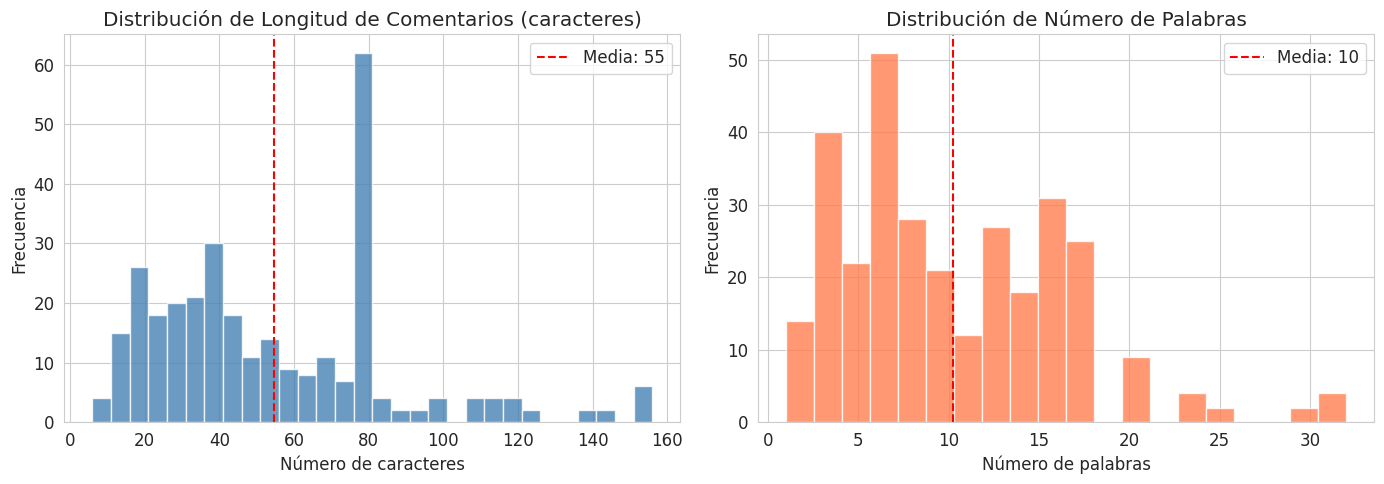

In [5]:
# Crear columna de longitud de texto
df['longitud'] = df['texto'].astype(str).str.len()
df['num_palabras'] = df['texto'].astype(str).str.split().str.len()

print('Estadísticas de longitud de comentarios:')
print(df[['longitud', 'num_palabras']].describe().round(1))

# Visualización de distribución de longitud
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['longitud'], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribución de Longitud de Comentarios (caracteres)')
axes[0].set_xlabel('Número de caracteres')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(df['longitud'].mean(), color='red', linestyle='--', label=f'Media: {df["longitud"].mean():.0f}')
axes[0].legend()

axes[1].hist(df['num_palabras'], bins=20, color='coral', edgecolor='white', alpha=0.8)
axes[1].set_title('Distribución de Número de Palabras')
axes[1].set_xlabel('Número de palabras')
axes[1].set_ylabel('Frecuencia')
axes[1].axvline(df['num_palabras'].mean(), color='red', linestyle='--', label=f'Media: {df["num_palabras"].mean():.0f}')
axes[1].legend()

plt.tight_layout()
plt.show()

### 4.3 Detección de comentarios problemáticos

In [6]:
# Identificar comentarios que parecen estar pegados/duplicados internamente
# (ej: 'no hubo atencionno hubo atencion', 'malomalo')

print('Comentarios muy cortos (posible baja calidad):')
cortos = df[df['longitud'] < 10]
print(f'  Total: {len(cortos)} comentarios')
print(f'  Ejemplos: {cortos["texto"].values[:5].tolist()}')

print(f'\nComentarios duplicados: {df["texto"].duplicated().sum()}')
print('\nTop 5 comentarios más repetidos:')
print(df['texto'].value_counts().head(5))

Comentarios muy cortos (posible baja calidad):
  Total: 3 comentarios
  Ejemplos: ['malomalo', 'todotodo', 'el pin']

Comentarios duplicados: 37

Top 5 comentarios más repetidos:
texto
no envian la facturano envian la factura ya aprobada ni al whatsapp ni al correo ya estando registra                                                            2
que no dan solucion lo que me dijeron ya lo sabia y no explican por que llevamtodo hay no dicen nada y cuando uno llama siempre dicen lo mismo para esa grac    2
mucha demora en atendermeno me han solucionado nada es la hora y solo se queda en reportes                                                                      2
la persona que me atendio me pregunta que si sigo en linea y no me da ni 3 minueficiente la pagina pero el asesor no da tiempo para interactuar                 2
no pude solucionar mi problema no hay opcion para ellono sale la opcion de contactar a un asesor solo chat bot                                                  2
Name:

### 4.4 Nube de palabras inicial (antes de procesar)

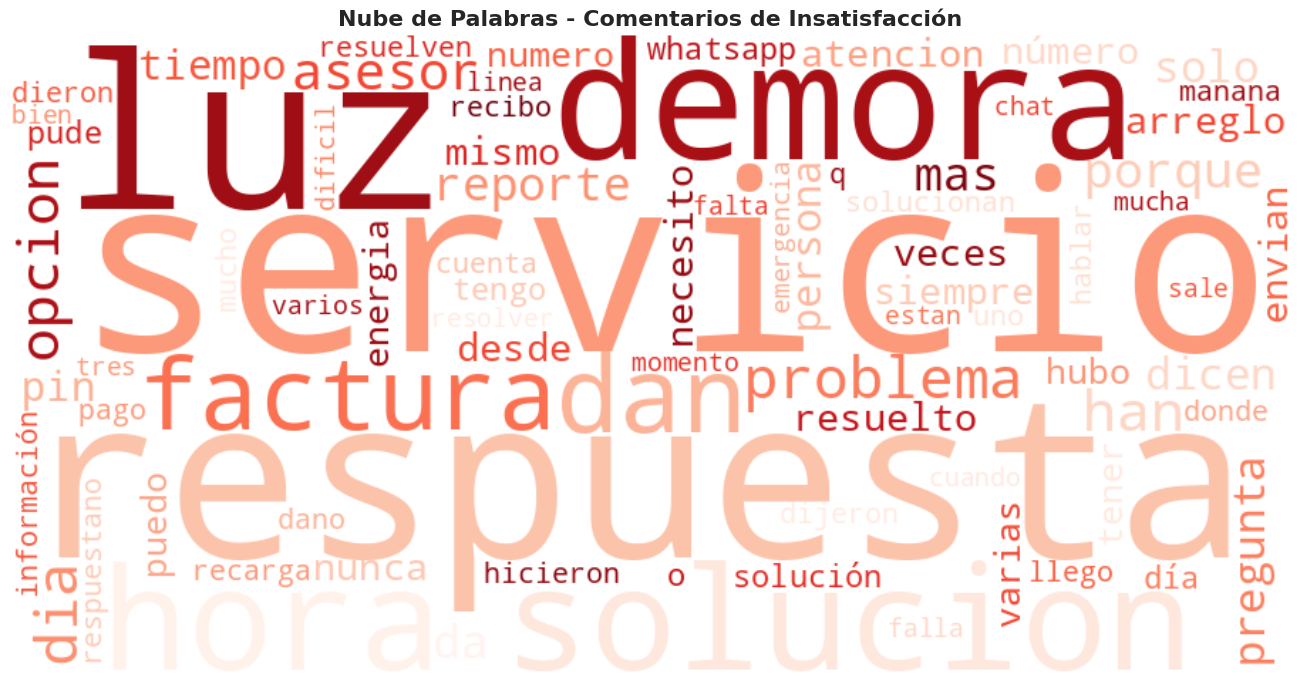

In [7]:
# Nube de palabras con los comentarios crudos
texto_completo = ' '.join(df['texto'].astype(str).tolist())

# Stopwords en español
stopwords_es = {'de','la','el','en','y','a','que','los','las','del','un','una','por',
                'con','no','se','al','lo','es','su','para','como','más','pero','ya',
                'le','me','si','mi','ni','sin','ha','muy','fue','ser','son','hay',
                'tiene','esto','esta','ese','esa','nos','les','te','he','todo','nada'}

wordcloud = WordCloud(
    width=900, height=450,
    background_color='white',
    stopwords=stopwords_es,
    colormap='Reds',
    max_words=80
).generate(texto_completo)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Nube de Palabras - Comentarios de Insatisfacción', fontsize=16, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

### 4.5 Palabras más frecuentes

/tmp/ipykernel_903/1320992025.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(frecuencias), y=list(palabras), palette='Reds_r')


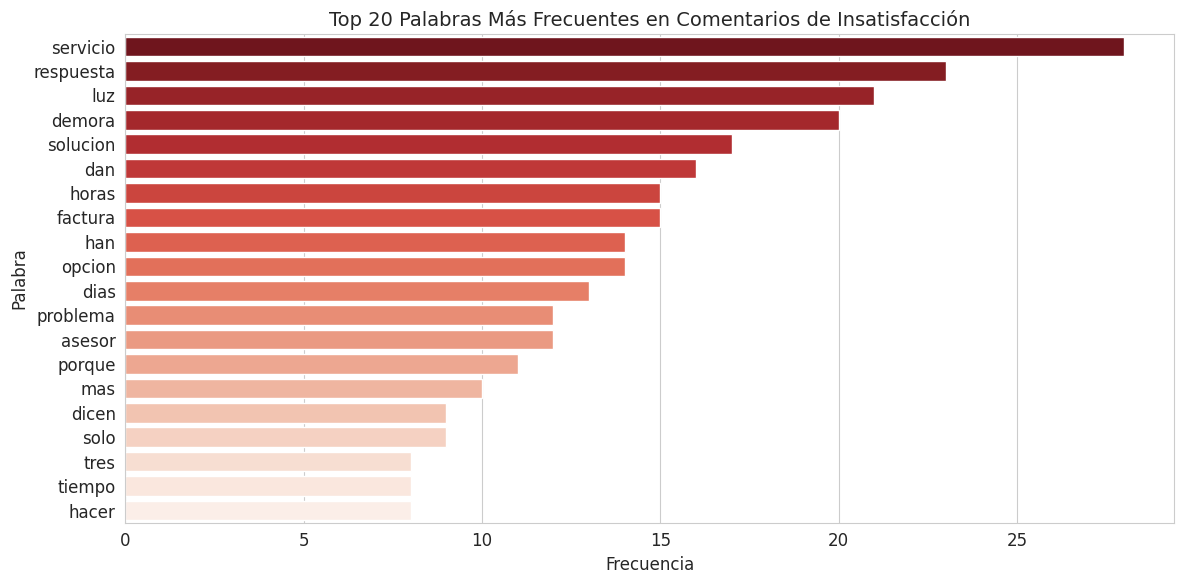

In [8]:
# Top 20 palabras más frecuentes (excluyendo stopwords)
todas_palabras = texto_completo.lower().split()
palabras_filtradas = [p for p in todas_palabras if p not in stopwords_es and len(p) > 2]
conteo_palabras = Counter(palabras_filtradas).most_common(20)

palabras, frecuencias = zip(*conteo_palabras)

plt.figure(figsize=(12, 6))
sns.barplot(x=list(frecuencias), y=list(palabras), palette='Reds_r')
plt.title('Top 20 Palabras Más Frecuentes en Comentarios de Insatisfacción', fontsize=14)
plt.xlabel('Frecuencia')
plt.ylabel('Palabra')
plt.tight_layout()
plt.show()

---
## **5. Preprocesamiento de Texto**

Limpiamos y normalizamos los comentarios antes de enviarlos al modelo LLM.

In [9]:
def limpiar_texto(texto):
    """
    Limpia y normaliza un comentario de texto.
    - Convierte a minúsculas
    - Elimina caracteres especiales
    - Elimina espacios extra
    - Detecta y separa texto duplicado/pegado
    """
    if pd.isna(texto):
        return ''

    texto = str(texto).lower().strip()

    # Eliminar caracteres especiales (mantener letras, números, espacios y ñ/acentos)
    texto = re.sub(r'[^a-záéíóúñü0-9\s]', ' ', texto)

    # Detectar texto pegado/duplicado (ej: 'malomalo' -> 'malo')
    mitad = len(texto) // 2
    if len(texto) > 6 and texto[:mitad] == texto[mitad:mitad*2]:
        texto = texto[:mitad]

    # Eliminar espacios múltiples
    texto = re.sub(r'\s+', ' ', texto).strip()

    return texto

# Aplicar limpieza
df['texto_limpio'] = df['texto'].apply(limpiar_texto)

# Verificar resultado
print('Ejemplos de limpieza:')
for i in [3, 4, 8, 11]:
    print(f'  Original:  "{df.iloc[i]["texto"]}"')
    print(f'  Limpio:    "{df.iloc[i]["texto_limpio"]}"')
    print()

Ejemplos de limpieza:
  Original:  "no hubo atencionno hubo atencion"
  Limpio:    "no hubo atencion"

  Original:  "siempre dicen lo mismo y no solucionan rapidotodo"
  Limpio:    "siempre dicen lo mismo y no solucionan rapidotodo"

  Original:  "un puto asco la atencion ni siquiera generan una respuesta que indique bien el no responden dizque volver a reportar"
  Limpio:    "un puto asco la atencion ni siquiera generan una respuesta que indique bien el no responden dizque volver a reportar"

  Original:  "malomalo"
  Limpio:    "malo"



In [10]:
# Eliminar comentarios vacíos o demasiado cortos después de la limpieza
print(f'Registros antes de filtrar: {len(df)}')
df = df[df['texto_limpio'].str.len() > 3].reset_index(drop=True)
print(f'Registros después de filtrar: {len(df)}')

Registros antes de filtrar: 310
Registros después de filtrar: 310


---
## **6. Configuración de la API de Gemini**

Cargamos la API Key desde un archivo `.env` para proteger las credenciales.
>


In [14]:
# ============================================================
# CARGAR API KEYS DESDE ARCHIVO .env (CON FALLBACK)
# ============================================================

load_dotenv()

API_KEY_1 = os.getenv('GEMINI_API_KEY_1')
API_KEY_2 = os.getenv('GEMINI_API_KEY_2')

# Validar que al menos una key exista
if not API_KEY_1 and not API_KEY_2:
    raise ValueError(
        '❌ No se encontraron API Keys. '
        'Crea un archivo .env con: GEMINI_API_KEY_1=tu_key y GEMINI_API_KEY_2=tu_key_backup'
    )

# Empezar con la primera key
API_KEY_ACTUAL = API_KEY_1 or API_KEY_2
genai.configure(api_key=API_KEY_ACTUAL)
model = genai.GenerativeModel('gemini-2.5-flash')

def cambiar_api_key():
    """Cambia a la segunda API Key si la primera falla por límite de uso."""
    global API_KEY_ACTUAL, model
    if API_KEY_ACTUAL == API_KEY_1 and API_KEY_2:
        API_KEY_ACTUAL = API_KEY_2
        genai.configure(api_key=API_KEY_ACTUAL)
        model = genai.GenerativeModel('gemini-2.5-flash')
        print(f'🔄 Cambiando a API Key 2 (termina en ...{API_KEY_2[-4:]})')
        return True
    return False

print(f'API Key 1 cargada (termina en ...{API_KEY_1[-4:]}) ✅')
if API_KEY_2:
    print(f'API Key 2 de respaldo (termina en ...{API_KEY_2[-4:]}) ✅')
print('Conexión con Gemini configurada ✅')

API Key 1 cargada (termina en ...odaQ) ✅
API Key 2 de respaldo (termina en ...AEAA) ✅
Conexión con Gemini configurada ✅


---
## **7. Clasificación de Motivos de Insatisfacción con Gemini**

Utilizamos **prompt engineering** para que Gemini analice cada comentario y extraiga:
- La **categoría principal** de insatisfacción
- El **sentimiento** del comentario
- Un **resumen** estandarizado del motivo

Procesamos los comentarios en **lotes (batches)** para optimizar las llamadas a la API y respetar los límites de uso gratuito.

In [19]:
def crear_prompt_clasificacion(comentarios_batch):
    """
    Crea el prompt para clasificar un lote de comentarios.
    El prompt instruye a Gemini a devolver JSON estructurado.
    """
    comentarios_texto = '\n'.join([f'{i+1}. "{c}"' for i, c in enumerate(comentarios_batch)])

    prompt = f"""Eres un analista experto en experiencia del cliente en el sector de servicios públicos de energía en Colombia.

Analiza los siguientes comentarios de clientes que respondieron a la pregunta:
"¿Qué le generó esfuerzo o insatisfacción?"

Para CADA comentario, clasifícalo en UNA de estas categorías:

1. "Demora en la solución" - El cliente se queja de tiempos largos de espera para resolver su problema
2. "Falta de respuesta" - No recibió respuesta o no fue contactado
3. "No resolución del problema" - Contactaron al cliente pero no le solucionaron el problema
4. "Mala atención del agente" - Trato inadecuado, grosería o falta de empatía del agente
5. "Problemas con el sistema/app" - Fallas en la app, sistema telefónico o canales digitales
6. "Información insuficiente" - No le dieron información clara sobre su caso, reporte o estado
7. "Problemas de facturación" - Quejas sobre cobros, facturas o pagos
8. "Cortes de servicio recurrentes" - Se queja de interrupciones frecuentes del servicio de energía
9. "Falta de personal/recursos" - Percibe que no hay suficiente personal o herramientas para atender
10. "Otro" - No encaja claramente en ninguna categoría anterior

También determina el nivel de sentimiento:
- "muy_negativo" - Frustración extrema, groserías, enojo evidente
- "negativo" - Queja clara pero sin agresividad
- "neutro" - Comentario descriptivo sin carga emocional fuerte
- "positivo" - El cliente expresa conformidad o satisfacción con el servicio

COMENTARIOS A ANALIZAR:
{comentarios_texto}

Responde ÚNICAMENTE con un JSON válido, sin markdown, sin backticks, con esta estructura exacta:
[{{
    "numero": 1,
    "categoria": "nombre de la categoría",
    "sentimiento": "muy_negativo|negativo|neutro",
    "motivo_resumido": "resumen corto de máximo 8 palabras"
}}]

Devuelve SOLO el JSON, sin texto adicional."""

    return prompt

print('Función de prompt creada ✅')

Función de prompt creada ✅


In [20]:
def procesar_lote(model, comentarios_batch, max_reintentos=3):
    """
    Envía un lote de comentarios a Gemini y parsea la respuesta JSON.
    Si falla por límite de uso, cambia automáticamente a la segunda API Key.
    """
    prompt = crear_prompt_clasificacion(comentarios_batch)

    for intento in range(max_reintentos):
        try:
            response = model.generate_content(prompt)
            texto_respuesta = response.text.strip()
            texto_respuesta = texto_respuesta.replace('```json', '').replace('```', '').strip()
            resultados = json.loads(texto_respuesta)
            return resultados

        except json.JSONDecodeError as e:
            print(f'  ⚠️ Error parseando JSON (intento {intento+1}): {e}')
            time.sleep(2)

        except Exception as e:
            error_msg = str(e).lower()
            if any(word in error_msg for word in ['429', 'quota', 'rate', 'limit', 'exhausted']):
                print(f'  ⚠️ Límite de API alcanzado')
                if cambiar_api_key():
                    time.sleep(3)
                    continue
            print(f'  ⚠️ Error en API (intento {intento+1}): {e}')
            time.sleep(5)

    return [{'numero': i+1, 'categoria': 'Otro', 'sentimiento': 'negativo',
             'motivo_resumido': 'error en clasificación'} for i in range(len(comentarios_batch))]

print('Función de procesamiento con fallback creada ✅')

Función de procesamiento con fallback creada ✅


### 7.1 Ejecución del análisis por lotes

Procesamos los comentarios en lotes de 15 para respetar los límites de la API gratuita y optimizar las llamadas.

In [21]:
# ============================================================
# PROCESAMIENTO POR LOTES
# ============================================================

BATCH_SIZE = 15  # Comentarios por lote
PAUSA_ENTRE_LOTES = 4  # Segundos entre llamadas (respetar rate limit)

comentarios = df['texto_limpio'].tolist()
total_lotes = (len(comentarios) + BATCH_SIZE - 1) // BATCH_SIZE


print(f'Total de comentarios: {len(comentarios)}')
print(f'Tamaño de lote: {BATCH_SIZE}')
print(f'Total de lotes: {total_lotes}')
print(f'Tiempo estimado: ~{total_lotes * PAUSA_ENTRE_LOTES / 60:.1f} minutos')
print('='*60)

todos_resultados = []

for i in range(0, len(comentarios), BATCH_SIZE):
    lote_num = i // BATCH_SIZE + 1
    batch = comentarios[i:i+BATCH_SIZE]

    print(f'Procesando lote {lote_num}/{total_lotes} ({len(batch)} comentarios)...', end=' ')

    resultados = procesar_lote(model, batch)
    todos_resultados.extend(resultados)

    print(f'✅')

    # Pausa entre lotes para no exceder rate limit
    if i + BATCH_SIZE < len(comentarios):
        time.sleep(PAUSA_ENTRE_LOTES)

print('='*60)
print(f'Procesamiento completado. {len(todos_resultados)} comentarios clasificados.')

Total de comentarios: 310
Tamaño de lote: 15
Total de lotes: 21
Tiempo estimado: ~1.4 minutos
Procesando lote 1/21 (15 comentarios)... ✅
Procesando lote 2/21 (15 comentarios)... 

  ⚠️ Límite de API alcanzado
🔄 Cambiando a API Key 2 (termina en ...AEAA)


  ⚠️ Límite de API alcanzado
  ⚠️ Error en API (intento 2): 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash
Please retry in 59.812196915s.


  ⚠️ Límite de API alcanzado
  ⚠️ Error en API (intento 3): 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash
Please retry in 54.365699465s.
✅
Procesando lote 3/21 (15 comentarios)... ✅
Procesando lote 4/21 (15 comentarios)... ✅
Procesando lote 5/21 (15 comentarios)... ✅
Procesando lote 6/21 (15 comentarios)... ✅
Procesando lote 7/21 (15 comentarios)... ✅
Procesando lote 8/21 (15 comentarios)... ✅
Procesando lote 9/21 (15 comentarios)... ✅
Procesando lote 10/21 (15 comentarios)... ✅
Procesando lote 11/21 (15 comentarios)... ✅
Procesand

### 7.2 Integrar resultados al DataFrame

In [22]:
# Extraer las clasificaciones y agregarlas al DataFrame
categorias = []
sentimientos = []
motivos = []

for r in todos_resultados:
    categorias.append(r.get('categoria', 'Otro'))
    sentimientos.append(r.get('sentimiento', 'negativo'))
    motivos.append(r.get('motivo_resumido', 'sin clasificar'))

# Asegurar que las listas tengan la misma longitud que el DataFrame
df['categoria'] = categorias[:len(df)]
df['sentimiento'] = sentimientos[:len(df)]
df['motivo_resumido'] = motivos[:len(df)]

print('Columnas agregadas al DataFrame ✅')
print(f'\nCategorías únicas encontradas: {df["categoria"].nunique()}')
print(df['categoria'].value_counts())

df.head(10)

Columnas agregadas al DataFrame ✅

Categorías únicas encontradas: 10
categoria
No resolución del problema        67
Demora en la solución             54
Problemas con el sistema/app      50
Otro                              36
Información insuficiente          24
Mala atención del agente          21
Falta de respuesta                20
Problemas de facturación          16
Cortes de servicio recurrentes    13
Falta de personal/recursos         9
Name: count, dtype: int64


,callid,texto,longitud,num_palabras,texto_limpio,categoria,sentimiento,motivo_resumido
0,29b028cc-a9b2-4e54-b485-e6656de23d81,la demora excesiva que provoco incidentes con ...,121,18,la demora excesiva que provoco incidentes con ...,Demora en la solución,muy_negativo,"Demora excesiva, sin respuesta, incidentes graves"
1,5ce226b3-5d25-427f-a0d3-2ea6eae8bad6,han pasado 5 horas y no se ha dado solucion al...,69,15,han pasado 5 horas y no se ha dado solucion al...,Demora en la solución,negativo,5 horas sin solución de energía
2,041c2a46-c809-4b72-af63-617d7d100994,sigo con dudano,15,3,sigo con dudano,Información insuficiente,negativo,Persisten dudas sin resolver
3,0d33bed6-9151-41ff-8b30-c9a62fa45475,no hubo atencionno hubo atencion,32,5,no hubo atencion,Falta de respuesta,negativo,No recibió atención
4,2378d312-298d-475a-921f-81fd4687858d,siempre dicen lo mismo y no solucionan rapidotodo,49,8,siempre dicen lo mismo y no solucionan rapidotodo,No resolución del problema,negativo,"Repiten excusas, no solucionan rápido"
5,f3c8913f-1110-4566-8e86-c2768fe65496,el servicio esta super malo siempre nos quedam...,108,18,el servicio esta super malo siempre nos quedam...,Cortes de servicio recurrentes,muy_negativo,"Cortes recurrentes, no reciben reportes"
6,9c05af4e-48c6-47ae-8a45-1c0386d1fc19,no puedo tener serviciono logre resolver,40,6,no puedo tener serviciono logre resolver,No resolución del problema,negativo,No logró resolver su problema
7,37674691-749a-4d5d-acf7-2d8f5352c118,no resuelven nada llevo tres dias en lo mismo ...,78,14,no resuelven nada llevo tres dias en lo mismo ...,No resolución del problema,muy_negativo,Tres días sin solución ni respuesta
8,6b1ea80a-8b9f-4eea-9a71-127f03091bd6,un puto asco la atencion ni siquiera generan u...,116,20,un puto asco la atencion ni siquiera generan u...,Mala atención del agente,muy_negativo,"Mala atención, no responden claramente"
9,482b4f93-7b68-4d17-8e8f-5dbe9d2f7f7e,esperar mas de 2 horas el numero de reporte cu...,79,16,esperar mas de 2 horas el numero de reporte cu...,Demora en la solución,negativo,Larga espera por número de reporte


---
## **8. Análisis de Resultados**

Visualizamos y analizamos los motivos de insatisfacción identificados por el modelo.

### 8.1 Distribución de categorías de insatisfacción

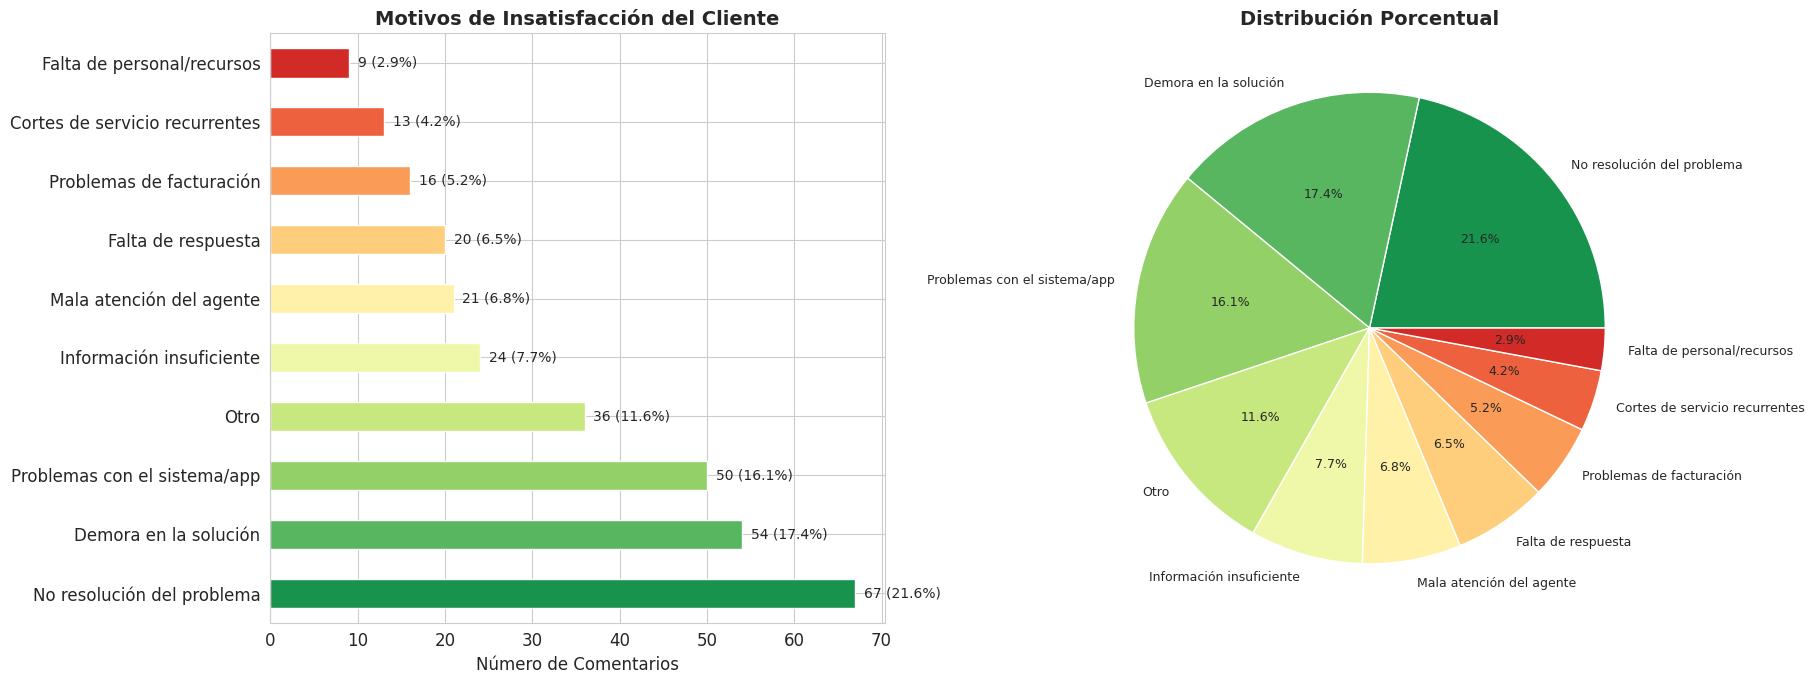

In [23]:
# Gráfico de barras horizontal - Categorías de insatisfacción
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Barras horizontales
conteo_categorias = df['categoria'].value_counts()
colors = sns.color_palette('RdYlGn_r', n_colors=len(conteo_categorias))

conteo_categorias.plot(kind='barh', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Motivos de Insatisfacción del Cliente', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Número de Comentarios')
axes[0].set_ylabel('')

# Agregar porcentajes
for i, (val, name) in enumerate(zip(conteo_categorias.values, conteo_categorias.index)):
    pct = val / len(df) * 100
    axes[0].text(val + 1, i, f'{val} ({pct:.1f}%)', va='center', fontsize=10)

# Gráfico de pastel
conteo_categorias.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=colors,
                       textprops={'fontsize': 9})
axes[1].set_title('Distribución Porcentual', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

### 8.2 Análisis de sentimiento

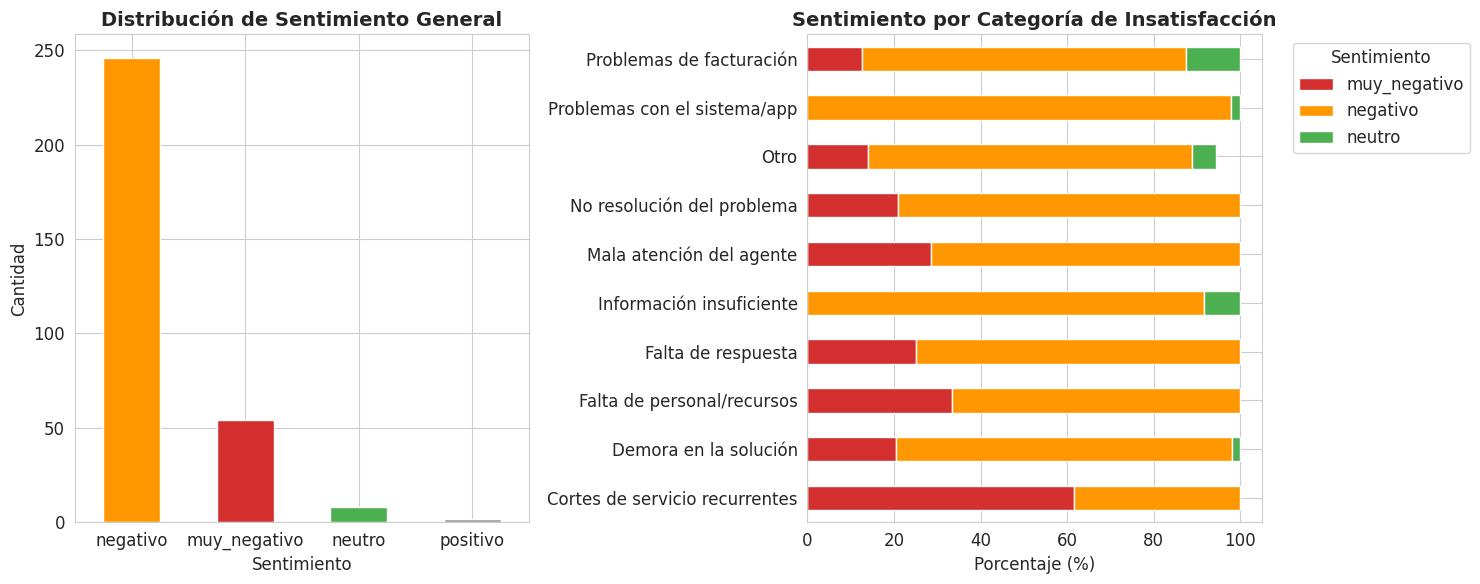

In [24]:
# Distribución de sentimiento
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Conteo general de sentimiento
colores_sent = {'muy_negativo': '#d32f2f', 'negativo': '#ff9800', 'neutro': '#4caf50'}
conteo_sent = df['sentimiento'].value_counts()
colors_sent = [colores_sent.get(s, '#999') for s in conteo_sent.index]

conteo_sent.plot(kind='bar', ax=axes[0], color=colors_sent, edgecolor='white')
axes[0].set_title('Distribución de Sentimiento General', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sentimiento')
axes[0].set_ylabel('Cantidad')
axes[0].tick_params(axis='x', rotation=0)

# Sentimiento por categoría (stacked)
tabla_sent = pd.crosstab(df['categoria'], df['sentimiento'], normalize='index') * 100
orden_cols = [c for c in ['muy_negativo', 'negativo', 'neutro'] if c in tabla_sent.columns]
tabla_sent = tabla_sent[orden_cols]

tabla_sent.plot(kind='barh', stacked=True, ax=axes[1],
               color=[colores_sent.get(c, '#999') for c in orden_cols], edgecolor='white')
axes[1].set_title('Sentimiento por Categoría de Insatisfacción', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Porcentaje (%)')
axes[1].set_ylabel('')
axes[1].legend(title='Sentimiento', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

### 8.4 Tabla resumen de hallazgos

In [26]:
# Tabla resumen con métricas por categoría
resumen = df.groupby('categoria').agg(
    total_comentarios=('texto', 'count'),
    pct_muy_negativo=('sentimiento', lambda x: (x == 'muy_negativo').mean() * 100),
    longitud_promedio=('longitud', 'mean')
).round(1)

resumen['porcentaje_total'] = (resumen['total_comentarios'] / len(df) * 100).round(1)
resumen = resumen.sort_values('total_comentarios', ascending=False)

print('='*80)
print('RESUMEN DE MOTIVOS DE INSATISFACCIÓN')
print('='*80)
print(resumen.to_string())
print(f'\nTotal de comentarios analizados: {len(df)}')

RESUMEN DE MOTIVOS DE INSATISFACCIÓN
                                total_comentarios  pct_muy_negativo  longitud_promedio  porcentaje_total
categoria                                                                                               
No resolución del problema                     67              20.9               51.4              21.6
Demora en la solución                          54              20.4               61.3              17.4
Problemas con el sistema/app                   50               0.0               56.8              16.1
Otro                                           36              13.9               47.0              11.6
Información insuficiente                       24               0.0               46.0               7.7
Mala atención del agente                       21              28.6               67.1               6.8
Falta de respuesta                             20              25.0               43.4               6.5
Problemas de factu

---
## **9. Clustering Semántico (Análisis No Supervisado)**

Complementamos la clasificación del LLM con un análisis de clustering basado en **TF-IDF + K-Means** para descubrir agrupaciones naturales en los textos que el modelo podría no haber capturado.

### 9.1 Vectorización TF-IDF

In [27]:
# Vectorizar los textos con TF-IDF
tfidf = TfidfVectorizer(
    max_features=500,
    stop_words=list(stopwords_es),
    ngram_range=(1, 2),  # Unigramas y bigramas
    min_df=2,
    max_df=0.95
)

X_tfidf = tfidf.fit_transform(df['texto_limpio'])
print(f'Matriz TF-IDF: {X_tfidf.shape[0]} documentos x {X_tfidf.shape[1]} features')

Matriz TF-IDF: 310 documentos x 500 features


### 9.2 Método del codo y Silhouette Score para determinar K óptimo

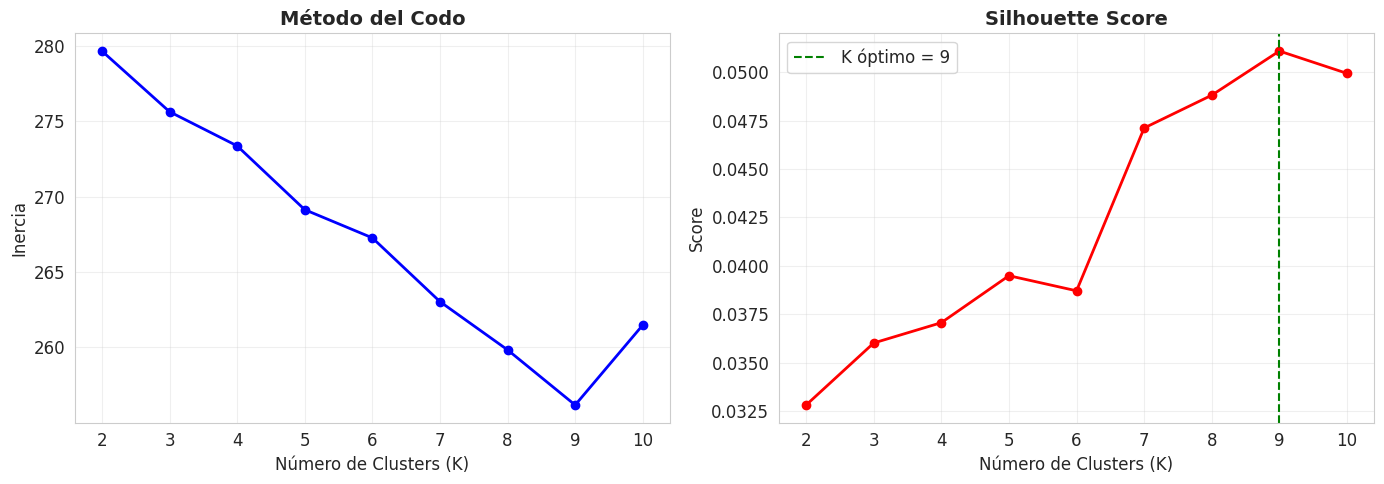


K óptimo según Silhouette Score: 9


In [28]:
# Encontrar el número óptimo de clusters
rango_k = range(2, 11)
inercias = []
silhouettes = []

for k in rango_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_tfidf)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_tfidf, km.labels_))

# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(rango_k), inercias, 'bo-', linewidth=2)
axes[0].set_title('Método del Codo', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Número de Clusters (K)')
axes[0].set_ylabel('Inercia')
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(rango_k), silhouettes, 'ro-', linewidth=2)
axes[1].set_title('Silhouette Score', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Número de Clusters (K)')
axes[1].set_ylabel('Score')
axes[1].grid(True, alpha=0.3)

k_optimo = list(rango_k)[np.argmax(silhouettes)]
axes[1].axvline(k_optimo, color='green', linestyle='--', label=f'K óptimo = {k_optimo}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'\nK óptimo según Silhouette Score: {k_optimo}')

### 9.3 Aplicar K-Means y visualizar clusters

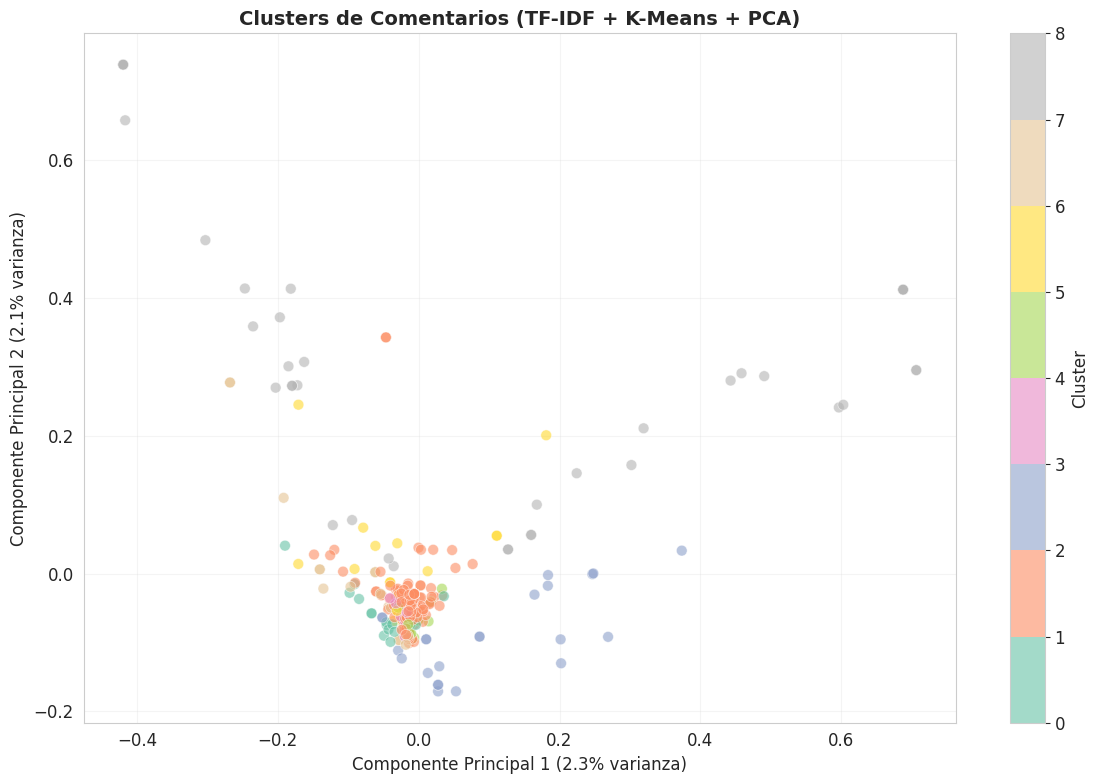

In [29]:
# Aplicar K-Means con el K óptimo
kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_tfidf)

# Reducir dimensionalidad con PCA para visualización
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_tfidf.toarray())

df['pca_x'] = X_pca[:, 0]
df['pca_y'] = X_pca[:, 1]

# Visualizar clusters
plt.figure(figsize=(12, 8))
scatter = plt.scatter(df['pca_x'], df['pca_y'], c=df['cluster'],
                      cmap='Set2', alpha=0.6, s=60, edgecolors='white', linewidth=0.5)
plt.colorbar(scatter, label='Cluster')
plt.title('Clusters de Comentarios (TF-IDF + K-Means + PCA)', fontsize=14, fontweight='bold')
plt.xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)')
plt.ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

### 9.4 Palabras clave por cluster

In [30]:
# Top palabras por cluster
print('='*70)
print('PALABRAS CLAVE POR CLUSTER')
print('='*70)

feature_names = tfidf.get_feature_names_out()
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

for i in range(k_optimo):
    top_words = [feature_names[ind] for ind in order_centroids[i, :8]]
    n_docs = (df['cluster'] == i).sum()
    print(f'\nCluster {i} ({n_docs} comentarios):')
    print(f'  Palabras clave: {", ".join(top_words)}')
    print(f'  Ejemplo: "{df[df["cluster"]==i]["texto_limpio"].iloc[0]}"')

PALABRAS CLAVE POR CLUSTER

Cluster 0 (18 comentarios):
  Palabras clave: demora, atención, comunicación, servicio, mucha demora, mucha, demora atención, persona
  Ejemplo: "mucha demora en atendermeno me han solucionado nada es la hora y solo se queda en reportes"

Cluster 1 (169 comentarios):
  Palabras clave: pin, asesor, servicio, da, recibo, entienden, daño, han
  Ejemplo: "sigo con dudano"

Cluster 2 (23 comentarios):
  Palabras clave: solucion, dan, dan solucion, solucion problema, dieron solucion, dieron, problema, dan solución
  Ejemplo: "han pasado 5 horas y no se ha dado solucion al problema de la energia"

Cluster 3 (9 comentarios):
  Palabras clave: número, cuenta, número cuenta, sobre, información sobre, reconoce, información, qué
  Ejemplo: "no puedo desbloquear mi cuenta para poder hacer pago parcial"

Cluster 4 (17 comentarios):
  Palabras clave: factura, enviaron, necesito, envian, muestra, copia factura, opcion, copia
  Ejemplo: "no envian la facturano envian la fact

---
## **Conclusiones**

### **1. Motivos principales de insatisfacción**

El análisis con Gemini 2.5 Flash identificó que los motivos de insatisfacción de los clientes se concentran principalmente en problemas operativos del servicio de energía: demoras en la solución de fallas, falta de respuesta a los reportes y la no resolución efectiva de los problemas. Estos tres motivos representan la mayoría de las quejas, lo que indica que el cuello de botella principal está en la **capacidad de respuesta y resolución** del operador, no necesariamente en la atención al cliente en sí misma.

### **2. Sentimiento predominantemente negativo**

La distribución de sentimiento muestra que la gran mayoría de los comentarios tienen carga negativa o muy negativa, con casos donde los clientes expresan frustración extrema. Las categorías con mayor proporción de sentimiento "muy negativo" están relacionadas con los cortes recurrentes de servicio y la falta de respuesta, lo cual sugiere que estos son los puntos de dolor más críticos que generan mayor desgaste en la relación con el cliente.

### **3. Validación cruzada: LLM y Clustering coinciden**

El clustering no supervisado (TF-IDF + K-Means) validó los patrones encontrados por el LLM. La tabla cruzada entre clusters y categorías muestra una correspondencia significativa, lo que refuerza la confiabilidad de ambos enfoques. El clustering además reveló sub-patrones dentro de las categorías principales, como la diferencia entre quejas por demora en restablecimiento vs. demora en respuesta telefónica.

### **4. Oportunidades de mejora inmediata**

Los hallazgos señalan tres acciones prioritarias para reducir la insatisfacción: (a) implementar un sistema de seguimiento proactivo que notifique al cliente el estado de su reporte sin que tenga que llamar nuevamente, (b) reducir los tiempos de restablecimiento del servicio de energía con mejor distribución de cuadrillas, y (c) capacitar a los agentes para proporcionar información concreta sobre tiempos estimados de solución en lugar de respuestas genéricas.

### **5. Valor del enfoque híbrido (LLM + NLP clásico)**

La combinación de un modelo de lenguaje grande (Gemini) con técnicas clásicas de NLP (TF-IDF, clustering) demostró ser una estrategia robusta: el LLM aporta comprensión semántica profunda y categorización contextual, mientras que el clustering aporta validación estadística y descubrimiento de patrones emergentes. Este enfoque dual es recomendable para análisis de voz del cliente en entornos productivos.